# Compute Raw PTR Values
April 2, 2024

Recompute the raw PTR values from the input G data. Update to use the 0.01 pseudocounts.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import load_yl_rg1_vst_config
from src.chromatin_model import ChromatinModel

def compute_g_ptr(gene_name, replicate):
    config1 = load_yl_rg1_vst_config(replicate)

    chromatin_model1 = ChromatinModel(config1)
    chromatin_model1.load_mnase_gene(gene_name, log=False)
    chromatin_model1.create_deconvolution_bins()

    # Compute the raw PTR for the gene for both replicates
    from src.peak_to_trough import compute_quantile_ptr

    mu0 = config1.intervals_wt1[0][0]

    # Compute the peak to trough ratio for non recovery timepoints
    non_RG1_G = chromatin_model1.G[chromatin_model1.timepoints > mu0, :]
    g_ptrs = np.apply_along_axis(lambda mat: compute_quantile_ptr(mat, 
        0.2, 0.8), 0, non_RG1_G)
    return g_ptrs


In [4]:
clb2_ptr = compute_g_ptr('CLB2', 1)
clb2_ptr.mean()

2.6517516049888785

In [12]:
from src.timer import Timer
from src.reference_data import load_analysis_genes

def get_g_ptrs_replicate(replicate, k=None):
    timer = Timer()
    
    geneset = load_analysis_genes()
    g_ptrs_df = None

    i = 0
    for orf_name, gene in geneset.iterrows():
        current_g_ptrs = compute_g_ptr(orf_name, replicate)

        if g_ptrs_df is None:        
            g_ptrs_df = pd.DataFrame(index=geneset.index.values,
                columns=np.arange(current_g_ptrs.shape[0]))

        g_ptrs_df.loc[orf_name, :] = current_g_ptrs

        if i % 100 == 0:
            print(f"{i}/{len(geneset)} - {timer.get_time()}")

        i += 1

    return g_ptrs_df


In [13]:
g_ptrs_1_df = get_g_ptrs_replicate(1)

0/5578 - 00:00:02.625
100/5578 - 00:05:41.321
200/5578 - 00:18:06.671
300/5578 - 00:26:29.740
400/5578 - 00:34:35.444
500/5578 - 00:41:26.312
600/5578 - 00:44:55.537
700/5578 - 00:57:38.744
800/5578 - 01:12:47.759
900/5578 - 01:27:57.581
1000/5578 - 01:43:08.928
1100/5578 - 01:58:19.793
1200/5578 - 02:13:36.317
1300/5578 - 02:29:59.302
1400/5578 - 02:40:41.535
1500/5578 - 02:46:59.556
1600/5578 - 02:53:10.703
1700/5578 - 02:56:20.018
1800/5578 - 03:06:11.369
1900/5578 - 03:17:49.960
2000/5578 - 03:29:17.542
2100/5578 - 03:40:51.695
2200/5578 - 03:52:24.385
2300/5578 - 03:59:26.922
2400/5578 - 04:05:04.531
2500/5578 - 04:10:30.426
2600/5578 - 04:14:59.556
2700/5578 - 04:20:00.978
2800/5578 - 04:27:45.528
2900/5578 - 04:35:29.415
3000/5578 - 04:43:11.597
3100/5578 - 04:50:27.957
3200/5578 - 04:57:46.377
3300/5578 - 05:05:19.686
3400/5578 - 05:17:19.855
3500/5578 - 05:31:10.239
3600/5578 - 05:45:00.538
3700/5578 - 05:58:51.755
3800/5578 - 06:12:46.658
3900/5578 - 06:22:37.987
4000/5578 - 

In [14]:
g_ptrs_2_df = get_g_ptrs_replicate(2)

0/5578 - 00:00:01.504
100/5578 - 00:03:29.494
200/5578 - 00:12:32.998
300/5578 - 00:21:37.734
400/5578 - 00:30:43.372
500/5578 - 00:38:22.737
600/5578 - 00:42:04.392
700/5578 - 00:56:39.401
800/5578 - 01:14:11.177
900/5578 - 01:31:33.447
1000/5578 - 01:48:47.338
1100/5578 - 02:05:58.230
1200/5578 - 02:23:03.478
1300/5578 - 02:40:14.394
1400/5578 - 02:51:18.797
1500/5578 - 02:57:54.619
1600/5578 - 03:04:31.299
1700/5578 - 03:07:55.052
1800/5578 - 03:18:22.624
1900/5578 - 03:30:31.473
2000/5578 - 03:42:43.645
2100/5578 - 03:54:54.562
2200/5578 - 04:07:06.575
2300/5578 - 04:14:41.477
2400/5578 - 04:20:45.553
2500/5578 - 04:26:37.363
2600/5578 - 04:31:28.808
2700/5578 - 04:36:55.171
2800/5578 - 04:44:55.310
2900/5578 - 04:52:55.480
3000/5578 - 05:00:56.841
3100/5578 - 05:08:40.474
3200/5578 - 05:16:17.769
3300/5578 - 05:23:54.445
3400/5578 - 05:36:15.404
3500/5578 - 05:50:48.016
3600/5578 - 06:05:25.303
3700/5578 - 06:19:52.932
3800/5578 - 06:34:22.041
3900/5578 - 06:45:02.123
4000/5578 - 

In [50]:
# g_ptrs_1_df.to_csv('output/raw_g_ptrs_eps_01/g_ptrs_chromatin_rep2.csv')
# g_ptrs_2_df.to_csv('output/raw_g_ptrs_eps_01/g_ptrs_chromatin_rep2.csv')

In [55]:
g_ptrs_1_df = pd.read_csv('output/raw_g_ptrs_eps_01/g_ptrs_chromatin_rep1.csv')
g_ptrs_2_df = pd.read_csv('output/raw_g_ptrs_old//g_ptrs_chromatin_rep1.csv')

g_ptrs_1_df = g_ptrs_1_df.rename(columns={'Unnamed: 0': 'orf_name'}).set_index('orf_name')
g_ptrs_2_df = g_ptrs_2_df.rename(columns={'Unnamed: 0': 'orf_name'}).set_index('orf_name')

In [56]:
raw1_mean_ptrs = g_ptrs_1_df.mean(axis=1)

In [57]:
raw2_mean_ptrs = g_ptrs_2_df.mean(axis=1)

PearsonRResult(statistic=-0.4155306505665796, pvalue=8.025343404693722e-232)

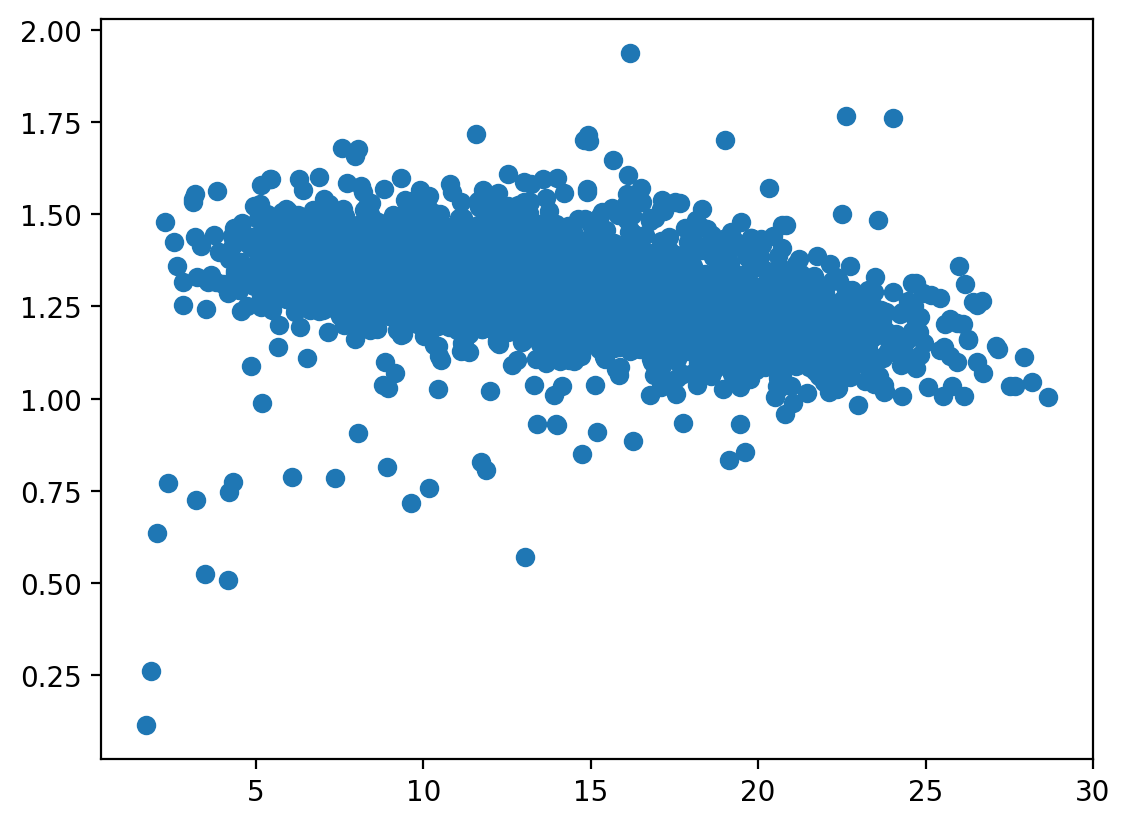

In [58]:
plt.scatter(raw1_mean_ptrs, raw2_mean_ptrs)
from scipy.stats import pearsonr
pearsonr(raw1_mean_ptrs, raw2_mean_ptrs)